In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

from sklearn.model_selection import (
    StratifiedGroupKFold,
    cross_validate,
    cross_val_predict
)

from sklearn.metrics import (
    make_scorer,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

data = pd.read_csv(
    output_dir / "sparrow_model_data.csv",
    dtype={"ID": "string"}
)

In [2]:
# choosing traning data
features = [
    "BuildingHeight",
    "BuildingWidth",
    "Altitude",
    "AveNoise",
    "temp",
    "prec",
    "win"
]

train = data.loc[data["Split"] == "train"].copy()
test = data.loc[data["Split"] == "test"].copy()

X_train = train[features]
y_train = train["HigherNestCount"]
groups_train = train["ID"]

assert set(train["ID"]).isdisjoint(set(test["ID"]))

print("Training rows:", len(train))
print("Reserved test rows:", len(test))

Training rows: 501
Reserved test rows: 156


In [3]:
# Cross-validation folds
cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

folds = list(
    cv.split(
        X_train,
        y_train,
        groups=groups_train
    )
)

fold_summary = []

for fold_number, (fit_idx, val_idx) in enumerate(folds, start=1):
    fit_groups = set(groups_train.iloc[fit_idx])
    val_groups = set(groups_train.iloc[val_idx])

    assert fit_groups.isdisjoint(val_groups)

    fold_summary.append({
        "Fold": fold_number,
        "FitRows": len(fit_idx),
        "ValidationRows": len(val_idx),
        "ValidationLower": int(
            (y_train.iloc[val_idx] == 0).sum()
        ),
        "ValidationHigher": int(
            (y_train.iloc[val_idx] == 1).sum()
        )
    })

display(pd.DataFrame(fold_summary))

,Fold,FitRows,ValidationRows,ValidationLower,ValidationHigher
0,1,404,97,56,41
1,2,400,101,60,41
2,3,382,119,70,49
3,4,407,94,42,52
4,5,411,90,48,42


In [4]:
# Set baseline and decision tree
models = {
    "Majority baseline": DummyClassifier(
        strategy="most_frequent"
    ),

    "Decision Tree": DecisionTreeClassifier(
        criterion="gini",
        max_depth=3,
        min_samples_leaf=10,
        random_state=42
    )
}

In [9]:
scoring = {
    "accuracy": "accuracy",

    "precision": make_scorer(
        precision_score,
        zero_division=0
    ),

    "recall": make_scorer(
        recall_score,
        zero_division=0
    ),

    "f1": make_scorer(
        f1_score,
        zero_division=0
    ),

    "roc_auc": "roc_auc"
}

In [10]:
comparison_rows = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=folds,
        scoring=scoring,
        error_score="raise"
    )

    row = {"Model": name}

    for metric in scoring:
        values = scores[f"test_{metric}"]

        row[f"{metric}_mean"] = values.mean()
        row[f"{metric}_std"] = values.std()

    comparison_rows.append(row)

comparison = pd.DataFrame(comparison_rows)

display(comparison.round(4))

,Model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,Majority baseline,0.5480,0.0549,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5000,0.0000
1,Decision Tree,0.6547,0.0405,0.6007,0.0546,0.7019,0.2064,0.6301,0.1024,0.6979,0.0604


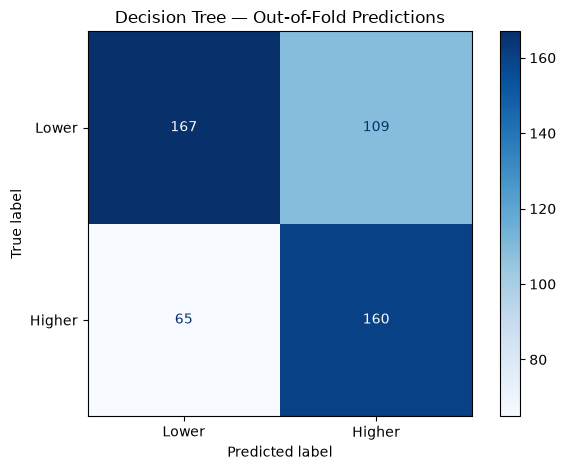

TN: 167
FP: 109
FN: 65
TP: 160


In [11]:
# confusion matrix
tree_oof_predictions = cross_val_predict(
    models["Decision Tree"],
    X_train,
    y_train,
    cv=folds,
    method="predict"
)

cm = confusion_matrix(
    y_train,
    tree_oof_predictions,
    labels=[0, 1]
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Lower", "Higher"]
).plot(cmap="Blues")

plt.title("Decision Tree — Out-of-Fold Predictions")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

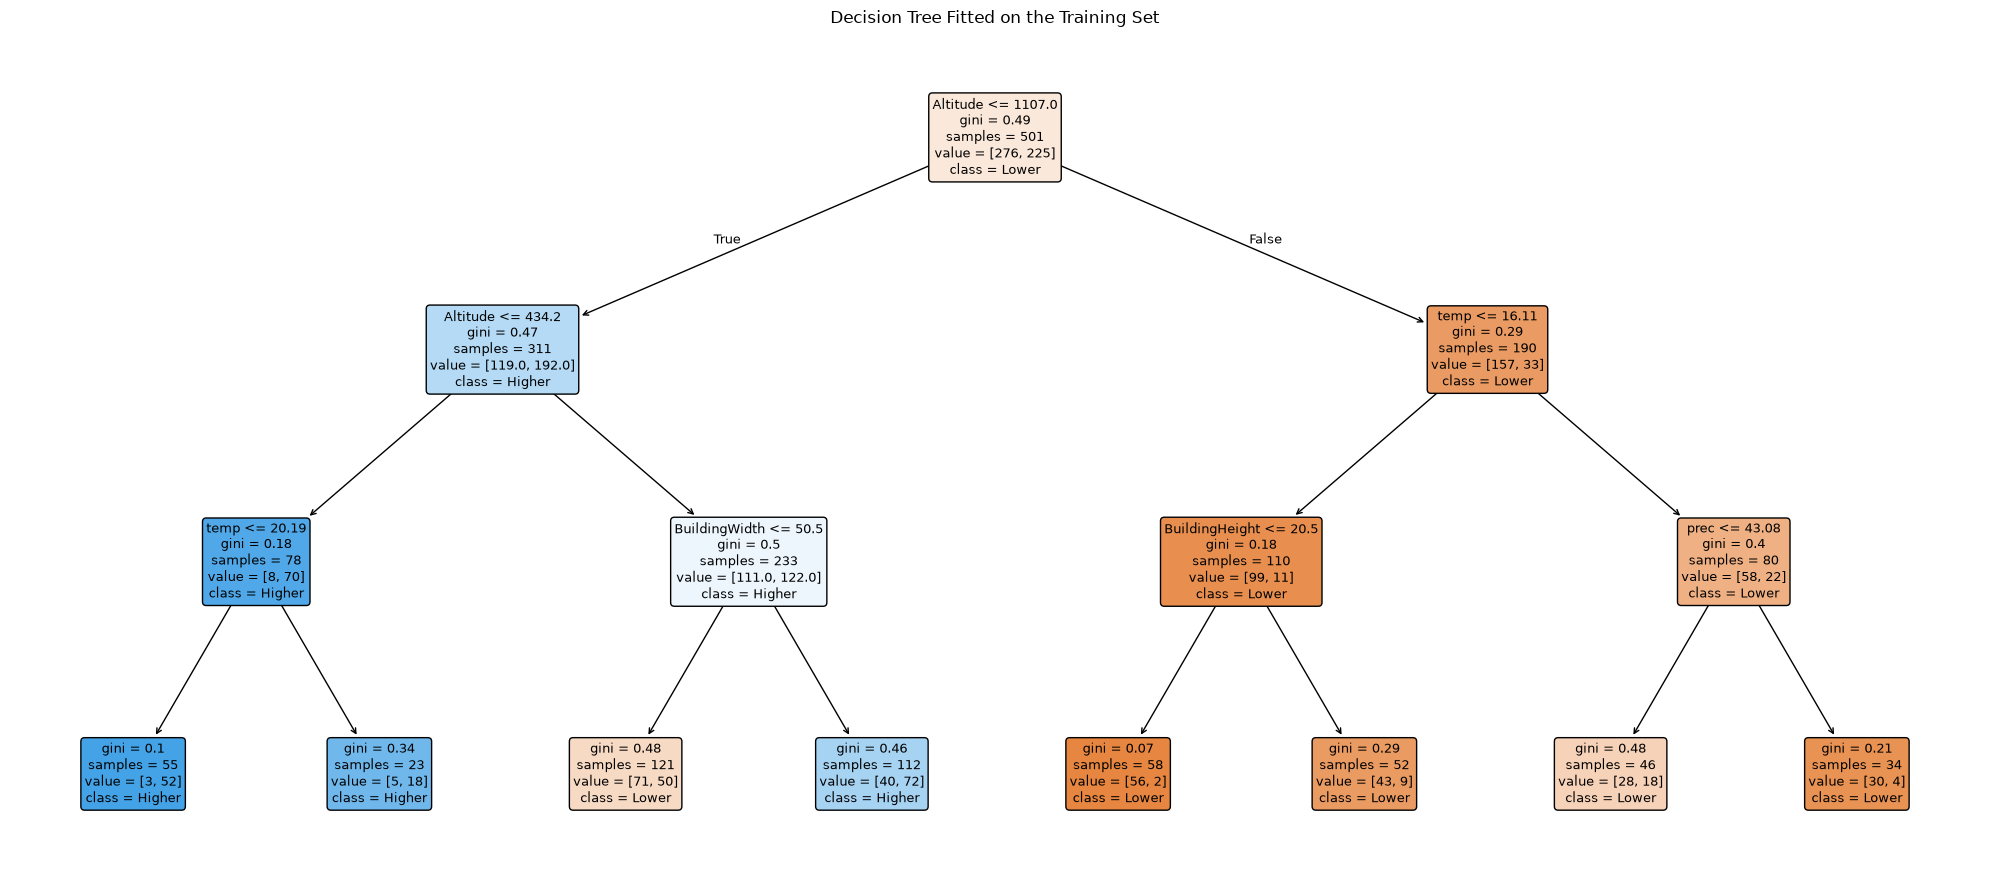

In [12]:
# Display Tree
tree_model = models["Decision Tree"]

tree_model.fit(X_train, y_train)

plt.figure(figsize=(20, 9))

plot_tree(
    tree_model,
    feature_names=features,
    class_names=["Lower", "Higher"],
    filled=True,
    rounded=True,
    precision=2,
    fontsize=9
)

plt.title("Decision Tree Fitted on the Training Set")
plt.tight_layout()

plt.savefig(
    output_dir / "decision_tree.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [13]:
# checking with IF-THEN rules
rules_text = export_text(
    tree_model,
    feature_names=features,
    decimals=2
)

print(rules_text)

|--- Altitude <= 1107.00
|   |--- Altitude <= 434.20
|   |   |--- temp <= 20.19
|   |   |   |--- class: 1
|   |   |--- temp >  20.19
|   |   |   |--- class: 1
|   |--- Altitude >  434.20
|   |   |--- BuildingWidth <= 50.50
|   |   |   |--- class: 0
|   |   |--- BuildingWidth >  50.50
|   |   |   |--- class: 1
|--- Altitude >  1107.00
|   |--- temp <= 16.11
|   |   |--- BuildingHeight <= 20.50
|   |   |   |--- class: 0
|   |   |--- BuildingHeight >  20.50
|   |   |   |--- class: 0
|   |--- temp >  16.11
|   |   |--- prec <= 43.08
|   |   |   |--- class: 0
|   |   |--- prec >  43.08
|   |   |   |--- class: 0



In [14]:
# save results
comparison.to_csv(
    output_dir / "classification_cv_results.csv",
    index=False
)

pd.DataFrame(fold_summary).to_csv(
    output_dir / "classification_cv_folds.csv",
    index=False
)

oof_results = train[
    ["SourceRowIndex", "Building#", "ID", "HigherNestCount"]
].copy()

oof_results["PredictedClass"] = tree_oof_predictions

oof_results["Correct"] = (
    oof_results["HigherNestCount"]
    == oof_results["PredictedClass"]
)

oof_results.to_csv(
    output_dir / "decision_tree_oof_predictions.csv",
    index=False
)

(output_dir / "decision_tree_rules.txt").write_text(
    rules_text,
    encoding="utf-8"
)

print("Classification results saved.")

Classification results saved.


In [15]:
# Checking 3 models - Naive Bayes, Logistic Reg, Random Forest
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

additional_models = {
    "Naive Bayes": GaussianNB(),

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
}

In [16]:
# Checking the folds as usual
new_rows = []

for name, model in additional_models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=folds,
        scoring=scoring,
        error_score="raise"
    )

    row = {"Model": name}

    for metric in scoring:
        values = scores[f"test_{metric}"]

        row[f"{metric}_mean"] = values.mean()
        row[f"{metric}_std"] = values.std()

    new_rows.append(row)

new_results = pd.DataFrame(new_rows)

comparison = pd.concat(
    [comparison, new_results],
    ignore_index=True
)

# Cell ပြန် run လုပ်ရင် model row ထပ်မနေစေဖို့
comparison = comparison.drop_duplicates(
    subset="Model",
    keep="last"
)

comparison = comparison.sort_values(
    "f1_mean",
    ascending=False
).reset_index(drop=True)

display(
    comparison[[
        "Model",
        "accuracy_mean",
        "precision_mean",
        "recall_mean",
        "f1_mean",
        "f1_std",
        "roc_auc_mean"
    ]].round(4)
)

,Model,accuracy_mean,precision_mean,recall_mean,f1_mean,f1_std,roc_auc_mean
0,Decision Tree,0.6547,0.6007,0.7019,0.6301,0.1024,0.6979
1,Random Forest,0.6841,0.6873,0.6283,0.6197,0.1143,0.7335
2,Logistic Regression,0.6678,0.6458,0.6024,0.5964,0.1372,0.7503
3,Naive Bayes,0.6704,0.7012,0.5688,0.5642,0.1773,0.7319
4,Majority baseline,0.5480,0.0000,0.0000,0.0000,0.0000,0.5000


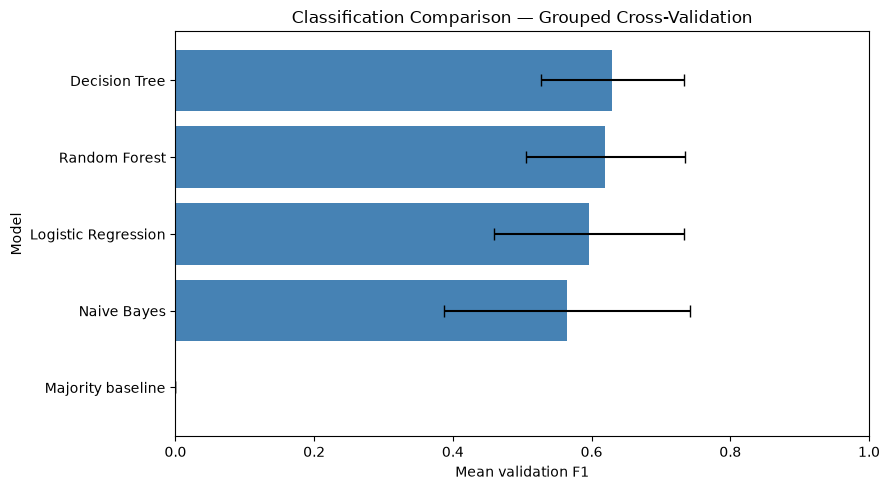

In [17]:
# Draw comparisan charts
plot_data = comparison.sort_values("f1_mean")

plt.figure(figsize=(9, 5))

plt.barh(
    plot_data["Model"],
    plot_data["f1_mean"],
    xerr=plot_data["f1_std"],
    capsize=4,
    color="steelblue"
)

plt.xlabel("Mean validation F1")
plt.ylabel("Model")
plt.title("Classification Comparison — Grouped Cross-Validation")
plt.xlim(0, 1)
plt.tight_layout()

plt.savefig(
    output_dir / "classification_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [18]:
# saved the results
comparison.to_csv(
    output_dir / "classification_cv_results.csv",
    index=False
)

models.update(additional_models)

print("Model comparison saved.")

Model comparison saved.
